# **Cardiac Rehabilitation Risk Prediction**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Loading of dataset
df = pd.read_excel('/content/drive/MyDrive/Cardiac/resources/Cleaned.xlsx')

In [ ]:
df.shape

(436, 48)

In [ ]:
df.head(15)

##Data Preparation

### Preliminary Data Analysis

In [ ]:
df.describe()

,Year,ID,DOB,Age,Muscle Power - UL - Right,Muscle Power - UL - Left,Muscle Power - LL - Right,Muscle Power - LL - Left,Target HR (%),Target HR (bpm),Recumbent bike : Duration,Recumbent bike : MHR,Recumbent bike : RPE
count,432.000000,436.000000,325,432.000000,329.000000,329.000000,328.000000,328.000000,289.000000,321.000000,308.000000,301.000000,305.000000
mean,2020.615741,218.500000,1963-09-06 00:08:51.692307680,58.891204,4.948328,4.948328,4.939024,4.935976,54.093426,104.027414,9.961039,103.843854,11.400000
min,2018.000000,1.000000,1935-09-03 00:00:00,21.000000,3.000000,2.000000,2.000000,2.000000,30.000000,58.000000,2.000000,43.000000,1.000000
25%,2020.000000,109.750000,1954-05-09 00:00:00,51.000000,5.000000,5.000000,5.000000,5.000000,50.000000,94.000000,10.000000,93.000000,11.000000
50%,2021.000000,218.500000,1962-07-29 00:00:00,61.000000,5.000000,5.000000,5.000000,5.000000,50.000000,104.000000,10.000000,105.000000,12.000000
75%,2022.000000,327.250000,1972-05-14 00:00:00,68.000000,5.000000,5.000000,5.000000,5.000000,60.000000,114.000000,10.000000,113.000000,13.000000
max,2022.000000,436.000000,1996-03-15 00:00:00,87.000000,5.000000,5.000000,5.000000,5.000000,80.000000,156.000000,20.000000,179.000000,14.000000
std,1.156253,126.006614,NaN,12.478277,0.282204,0.312940,0.296671,0.330209,6.595052,15.160248,1.273038,16.274485,2.653944


In [ ]:
df.dtypes

,0
Year,float64
ID,int64
DOB,datetime64[ns]
Gender,object
Age,float64
Marital Status,object
Lives With,object
Living Environment,object
Occupation,object
Smoking,object


In [ ]:
#Checking for null values in each column
df.isna().sum()

,0
Year,4
ID,0
DOB,111
Gender,4
Age,4
Marital Status,4
Lives With,4
Living Environment,4
Occupation,4
Smoking,4


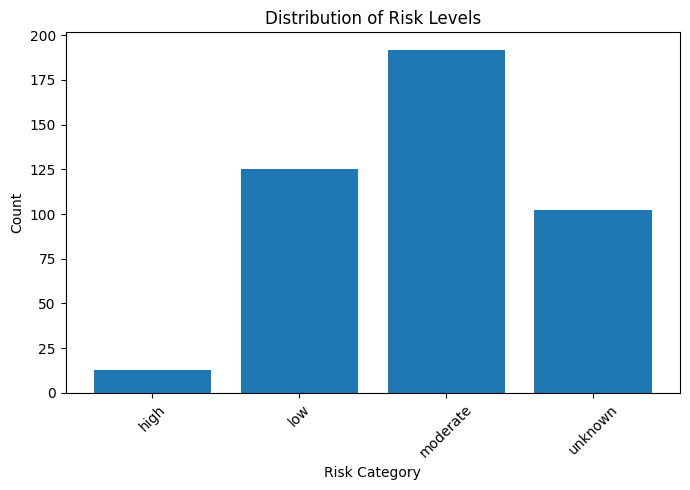

In [ ]:
#Generating a distribution plot of target variable (Risk Level)
risk_counts = df["Risk Level"].value_counts().sort_index()
plt.figure(figsize=(7,5))
plt.bar(risk_counts.index, risk_counts.values)
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.title("Distribution of Risk Levels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(risk_counts)

Risk Level
high         13
low         125
moderate    192
unknown     102
Name: count, dtype: int64


The dataset is **severely imbalanced**, with a very small number of high-risk cases compared to the low- and moderate-risk groups. To address this issue, the problem is reformulated as a **binary classification** task, where **low risk is encoded as 0**, and **moderate and high risk are combined and encoded as 1**. This transformation helps improve class balance and model stability while preserving the clinical relevance of identifying at-risk patients.

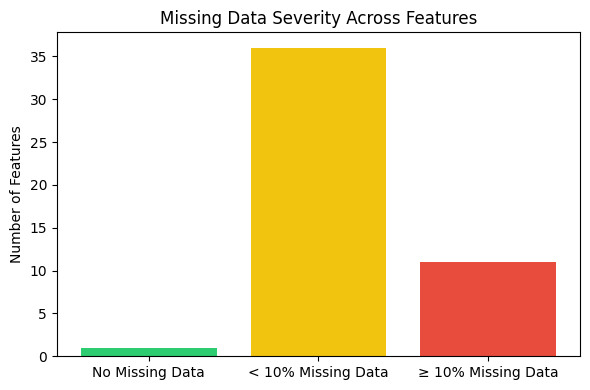

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate missing percentage per feature
missing_pct = df.isnull().mean() * 100

# Define bins and labels
bins = [-0.01, 0, 10, 100]
labels = [
    "No Missing Data",
    "< 10% Missing Data",
    "≥ 10% Missing Data"
]

# Bin features by missingness
missing_bins = pd.cut(
    missing_pct,
    bins=bins,
    labels=labels
)

# Count features in each category
bin_counts = missing_bins.value_counts().reindex(labels)

# Plot
plt.figure(figsize=(6, 4))
plt.bar(
    bin_counts.index,
    bin_counts.values,
    color=["#2ecc71", "#f1c40f", "#e74c3c"]
)

plt.ylabel("Number of Features")
plt.title("Missing Data Severity Across Features")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Calculate missing percentage per feature
missing_pct = df.isnull().mean() * 100

# Define bins and labels
bins = [-0.01, 0, 10, 100]
labels = [
    "No Missing Data",
    "< 10% Missing Data",
    "≥ 10% Missing Data"
]

# Bin features
missing_bins = pd.cut(missing_pct, bins=bins, labels=labels)

# Create numeric summary table
missing_summary = (
    missing_bins
    .value_counts()
    .reindex(labels)
    .reset_index()
)

missing_summary.columns = ["Missing Data Category", "Number of Features"]

missing_summary


,Missing Data Category,Number of Features
0,No Missing Data,1
1,< 10% Missing Data,36
2,≥ 10% Missing Data,11


### Handling Missing Values

In [ ]:
#Convert "unknown" entries to NaN to allow model to properly handle missing values
df = df.replace("unknown", np.nan)

In [ ]:
#Dropping rows where Year and Risk Level (target) is null
df = df.dropna(subset=['Year','Risk Level'])
df = df.reset_index(drop=True)

In [ ]:
#Both columns has the unique values
df[['Smoking', 'Risk Factor - Smoking']].isna().sum()

,0
Smoking,115
Risk Factor - Smoking,82


In [ ]:
#Merging 'Smoking' and 'Risk Factor - Smoking' into a single column to reduce redundancy
df['Risk Factor - Smoking'] = df['Smoking'].combine_first(df['Risk Factor - Smoking'])

In [ ]:
#Drop columns - ID, DOB, Marital Status, Smoking & RISK  - Risk Type
df.drop(['ID', 'DOB', 'Smoking', 'Marital Status', 'RISK  - Risk Type'], axis=1, inplace=True)

In [ ]:
missing_percentage = df.isna().mean().sort_values(ascending=False)
missing_percentage[missing_percentage > 0]

,0
Alcoholic,0.684848
Living Environment,0.548485
Risk Factor - HPL,0.527273
Exercise Habit - Duration,0.460606
Risk Factor - ECHO - EF,0.457576
ECG Resting,0.424242
Risk Factor - HPT,0.403030
Family History,0.381818
Occupation,0.360606
Exercise Habit - Frequency,0.354545


In [ ]:
df.drop(['Year','Alcoholic', 'Living Environment'], axis=1, inplace=True)

### Encoding and Feature Engineering

In [ ]:
#Display number of unique values and the actual unique entries in each column
for col in df.columns:
    print(f"Column: {col}")
    print(f"Total unique values: {df[col].nunique()}")
    print(df[col].unique())
    print("-" * 40)

Column: Gender
Total unique values: 2
['M' 'F']
----------------------------------------
Column: Age
Total unique values: 57
[53. 69. 70. 74. 51. 66. 64. 63. 59. 67. 75. 47. 36. 56. 60. 71. 65. 55.
 68. 54. 52. 80. 45. 42. 62. 41. 48. 72. 40. 50. 43. 33. 46. 58. 78. 38.
 76. 37. 73. 57. 34. 86. 84. 49. 44. 35. 61. 29. 39. 77. 27. 28. 81. 87.
 26. 85. 79.]
----------------------------------------
Column: Lives With
Total unique values: 3
['family' nan 'friends' 'alone ']
----------------------------------------
Column: Occupation
Total unique values: 4
['not working' 'retired' nan 'employed' 'self employed']
----------------------------------------
Column: Family History
Total unique values: 2
['yes' 'no' nan]
----------------------------------------
Column: Exercise Habit - Frequency
Total unique values: 16
['7 times per week' nan '2 times per week' '0 times per week'
 '4 times per week' '2-3 times per week' '6 times per week'
 '5 times per week' '1 times per week' '1-2 times per week'

In [ ]:
len(df.columns)

40

In [ ]:
#Standardize string values (Removing extra whitespace, lowercasing)
df.columns = df.columns.str.strip()
df = df.applymap(lambda x: x.strip().lower() if isinstance(x, str) else x)

/tmp/ipython-input-2486140890.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip().lower() if isinstance(x, str) else x)


**Standardizing messy categorical columns**

In [ ]:
import re

In [ ]:
#Exercise Habit - Frequency, Duration
def messy_value (val):
    if pd.isna(val):
        return np.nan

    #Extract all numbers in the string
    numbers = list(map(int, re.findall(r'\d+', val)))

    if len(numbers) == 1:
        return numbers[0]
    elif len(numbers) == 2:
        return sum(numbers) / 2
    else:
        return np.nan

df['Exercise Habit - Frequency'] = df['Exercise Habit - Frequency'].apply(messy_value)
df['Exercise Habit - Duration'] = df['Exercise Habit - Duration'].apply(messy_value)

In [ ]:
#Removing outliers
df['Exercise Habit - Duration'] = df['Exercise Habit - Duration'].clip(upper=120)

In [ ]:
#Recumbent bike : RES
def parse_recumbent_res(val):
    if pd.isna(val):
        return np.nan

    #Convert to string
    val = str(val)

    #Handle known non-informative text
    if 'confirm' in val.lower():
        return np.nan

    #Extract numbers
    numbers = list(map(int, re.findall(r'\d+', val)))

    if len(numbers) == 1:
        return numbers[0]
    elif len(numbers) == 2:
        return sum(numbers) / 2
    else:
        return np.nan

df['Recumbent bike : RES'] = df['Recumbent bike : RES'].apply(parse_recumbent_res)

**Standardizing combined categorical variables**

[Exercise Habit - Mode, Test Today - Termination Cause, ECG Resting, Diagnosis]

In [ ]:
#Exercise Habit - Mode
exercise_modes = ['walking', 'jogging', 'cycling']

for mode in exercise_modes:
    df[f'exercise_{mode}'] = (
        df['Exercise Habit - Mode']
        .fillna('')
        .str.lower()
        .apply(lambda x: int(mode in [c.strip() for c in x.split('+')]))
    )

#Does the patient exercise at all?
df['exercise_any'] = (
    df['Exercise Habit - Mode']
    .fillna('')
    .str.lower()
    .apply(lambda x: int(x not in ['', 'no']))
)

In [ ]:
#Test Today - Termination Cause
termination_causes = [
    'fatigue',
    'medical condition',
    'physical discomfort',
    'complete test'
]

for cause in termination_causes:
    df[f'termination_{cause.replace(" ", "_")}'] = (
        df['Test Today - Termination Cause']
        .fillna('')
        .str.lower()
        .apply(lambda x: int(cause in [c.strip() for c in x.split('+')]))
    )

#Was the test stopped or completed?
df['termination_adverse'] = (
    df[['termination_fatigue',
         'termination_medical_condition',
         'termination_physical_discomfort']]
    .sum(axis=1) > 0
).astype(int)

In [ ]:
#ECG Resting
ecg_features = [
    'sinus rhythm',
    'st depression',
    't wave inversion',
    'q wave',
    'ectopics',
    'normal'
]

for feature in ecg_features:
    df[f'ecg_{feature.replace(" ", "_")}'] = (
        df['ECG Resting']
        .fillna('')
        .str.lower()
        .apply(lambda x: int(feature in [c.strip() for c in x.split('+')]))
    )

#Was there any ECG abnormality?
df['ecg_abnormal'] = (
    df[['ecg_st_depression',
         'ecg_t_wave_inversion',
         'ecg_q_wave',
         'ecg_ectopics']]
    .sum(axis=1) > 0
).astype(int)

In [ ]:
#Diagnosis
diagnosis_types = [
    'pci',
    'cabg',
    'surgical',
    'conservative'
]

for dx in diagnosis_types:
    df[f'dx_{dx}'] = (
        df['Diagnosis']
        .fillna('')
        .str.lower()
        .apply(lambda x: int(dx in [c.strip() for c in x.split('+')]))
    )

#Was there any invasive cardiac intervention?
df['dx_invasive'] = (
    df[['dx_pci', 'dx_cabg', 'dx_surgical']]
    .sum(axis=1) > 0
).astype(int)

#Conservative treatment only (no invasive procedures)
df['dx_conservative_only'] = (
    (df['dx_conservative'] == 1) &
    (df[['dx_pci', 'dx_cabg', 'dx_surgical']].sum(axis=1) == 0)
).astype(int)


In [ ]:
#Create LEFT muscle power (UL + LL)
df['muscle_power_left'] = df[
    ['Muscle Power - UL - Left', 'Muscle Power - LL - Left']
].mean(axis=1, skipna=True)

#Create RIGHT muscle power (UL + LL)
df['muscle_power_right'] = df[
    ['Muscle Power - UL - Right', 'Muscle Power - LL - Right']
].mean(axis=1, skipna=True)

In [ ]:
df.drop(['Exercise Habit - Mode','Test Today - Termination Cause','ECG Resting','Diagnosis',], axis=1, inplace=True)

In [ ]:
df.drop(['Target HR (bpm)'], axis=1, inplace=True)
#Target HR (%)

In [ ]:
df = df.rename(columns={'Target HR (%)': 'Heart Rate (%)'})

In [ ]:
features_to_drop = [
    'Recumbent bike : MHR',
    'Recumbent bike : RES',
    'Recumbent bike : RPE',
    'Recumbent bike : Duration',
    'Muscle Power - UL - Left',
    'Muscle Power - LL - Left',
    'Muscle Power - UL - Right',
    'Muscle Power - LL - Right',
    'Cooling Down',
    'exercise_walking',
    'exercise_jogging',
    'exercise_cycling',
    'termination_fatigue',
    'termination_complete_test',
    'termination_medical_condition',
    'termination_physical_discomfort'
]

In [ ]:
df.drop(columns=features_to_drop, axis=1, inplace=True)

**Target (Binary Classification)**

In [ ]:
df['Risk Level'] = df['Risk Level'].map({
    'low': 0,
    'moderate': 1,
    'high': 1
})

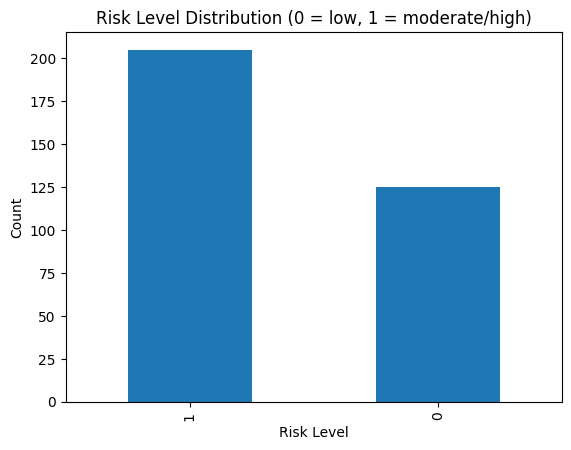

In [ ]:
df['Risk Level'].value_counts().plot(
    kind='bar',
    title='Risk Level Distribution (0 = low, 1 = moderate/high)'
)
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()

###Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
TARGET_COL = 'Risk Level'

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

###Data Oversampling using CTGAN

In [ ]:
train_ctgan = X_train_raw.copy()
train_ctgan[TARGET_COL] = y_train.values

In [ ]:
#Identifying categorical columns and numeric columns
categorical_cols = X_train_raw.select_dtypes(include=['object']).columns
numeric_cols = X_train_raw.select_dtypes(include=['int64', 'float64']).columns
ctgan_categorical_cols = list(categorical_cols)

In [ ]:
pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.5/198.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.5/198.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.8 MB/s eta 0:00:00


In [ ]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_ctgan)

# Explicitly mark target as numerical
metadata.update_column(
    column_name=TARGET_COL,
    sdtype="numerical"
)

ctgan = CTGANSynthesizer(
    metadata=metadata,
    epochs=300,
    batch_size=500,
    verbose=True
)

ctgan.fit(train_ctgan)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (0.77) | Discrim. (0.27): 100%|██████████| 300/300 [00:21<00:00, 13.66it/s]


In [ ]:
class_counts = train_ctgan[TARGET_COL].value_counts()

minority_class = class_counts.idxmin()
majority_class = class_counts.idxmax()

n_needed = int(class_counts[majority_class] - class_counts[minority_class])

print("Class counts before CTGAN:")
print(class_counts)
print("Minority class:", minority_class)
print("Majority class:", majority_class)
print("Synthetic samples needed:", n_needed)

Class counts before CTGAN:
Risk Level
1    164
0    100
Name: count, dtype: int64
Minority class: 0
Majority class: 1
Synthetic samples needed: 64


In [ ]:
if n_needed <= 0:
    print("Training data already balanced. Skipping CTGAN oversampling.")
    train_augmented = train_ctgan.copy()
else:
    #Generate MORE samples than needed
    synthetic_data = ctgan.sample(num_rows=n_needed * 3)

    #Keep ONLY minority class
    synthetic_minority = synthetic_data[
        synthetic_data[TARGET_COL] == minority_class
    ]

    #Enforce exact balance
    synthetic_minority = synthetic_minority.sample(
        n=n_needed,
        replace=True,
        random_state=42
    )

    #Combine real + synthetic
    train_augmented = pd.concat(
        [train_ctgan, synthetic_minority],
        axis=0
    ).sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
X_train_aug = train_augmented.drop(columns=[TARGET_COL])
y_train_aug = train_augmented[TARGET_COL]

In [ ]:
print("\nClass distribution AFTER CTGAN:")
print(y_train_aug.value_counts())

print("\nPercentages:")
print(y_train_aug.value_counts(normalize=True) * 100)


Class distribution AFTER CTGAN:
Risk Level
0    164
1    164
Name: count, dtype: int64

Percentages:
Risk Level
0    50.0
1    50.0
Name: proportion, dtype: float64


In [ ]:
#Train-Test Split for CatBoost
#Training data (augmented)
X_train = X_train_aug.copy()
y_train = y_train_aug.copy()

#Test data
X_test = X_test_raw.copy()
y_test = y_test.copy()

In [ ]:
#X_train = X_train.drop(columns=["Test Today - METS", "Heart Rate (%)"])
#X_test  = X_test.drop(columns=["Test Today - METS", "Heart Rate (%)"])

###Data Imputation

In [ ]:
#Identifying categorical columns and numeric columns
categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
#Imputing NaN values with 'missing' for categorical columns only
X_train[categorical_cols] = X_train[categorical_cols].fillna('missing')
X_test[categorical_cols] = X_test[categorical_cols].fillna('missing')

###Model-Specific Preprocessing and Encoding (XGB, RF & ANN)



In [ ]:
X_train_encoded = X_train_aug.copy()
y_train_encoded = y_train_aug.copy()

X_test_encoded  = X_test_raw.copy()
y_test_encoded  = y_test.copy()

In [ ]:
#Encoding binary variables
binary_maps = {
    'Gender': {'m': 0, 'f': 1},
    'Family History': {'no': 0, 'yes': 1},
    'ROM': {'normal': 0, 'abnormal': 1},
    'Balance in Sitting and Standing': {'no': 0, 'yes': 1},
    'Functional Activity': {'independent': 0, 'assisted': 1},
    'Walking': {'independent': 0, 'dependent': 1},
    'Gait': {'normal': 0, 'abnormal': 1},
    'Posture': {'normal': 0, 'abnormal': 1},
    'Risk Factor - HPT': {'no': 0, 'yes': 1},
    'Risk Factor - DM': {'no': 0, 'yes': 1},
    'Risk Factor - HPL': {'no': 0, 'yes': 1},
    'Risk Factor - Family hx': {'no': 0, 'yes': 1},
    'Risk Factor - Stress': {'no': 0, 'yes': 1}
}

for col, mapping in binary_maps.items():
    X_train_encoded[col] = X_train_encoded[col].map(mapping)
    X_test_encoded[col]  = X_test_encoded[col].map(mapping)

In [ ]:
#Identifying categorical columns and numeric columns
categorical_cols_encoded = X_train_encoded.select_dtypes(include=['object']).columns
numeric_cols_encoded = X_train_encoded.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
#Imputing missing for categorical NaNs
X_train_encoded[categorical_cols_encoded] = X_train_encoded[categorical_cols_encoded].fillna('missing')
X_test_encoded[categorical_cols_encoded]  = X_test_encoded[categorical_cols_encoded].fillna('missing')

In [ ]:
#Creating missing flags for numeric NaNs
missing_flag_cols = []

for col in numeric_cols:
    flag_col = f'{col}_missing'
    missing_flag_cols.append(flag_col)

    X_train_encoded[flag_col] = X_train_encoded[col].isna().astype(int)
    X_test_encoded[flag_col]  = X_test_encoded[col].isna().astype(int)

In [ ]:
#Imputing numeric NaNs with median
median_vals = X_train_encoded[numeric_cols_encoded].median()

X_train_encoded[numeric_cols_encoded] = X_train_encoded[numeric_cols_encoded].fillna(median_vals)
X_test_encoded[numeric_cols_encoded]  = X_test_encoded[numeric_cols_encoded].fillna(median_vals)


In [ ]:
numeric_cols_encoded = list(numeric_cols_encoded) + missing_flag_cols

In [ ]:
#Encoding remaining categorical variables using OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_enc = ohe.fit_transform(X_train_encoded[categorical_cols_encoded])
X_test_enc  = ohe.transform(X_test_encoded[categorical_cols_encoded])

In [ ]:
#Extract numeric matrix
X_train_num = X_train_encoded[numeric_cols_encoded].values
X_test_num  = X_test_encoded[numeric_cols_encoded].values

#Combine numeric + one-hot categorical
X_train_final = np.hstack([X_train_num, X_train_enc])
X_test_final  = np.hstack([X_test_num, X_test_enc])

##Feature Exhaustion

In [ ]:
!pip install CatBoost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00


In [ ]:
X_train_fs = X_train.copy()
y_train_fs = y_train.copy()

In [ ]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
X_train_fs[numeric_cols] = num_imputer.fit_transform(X_train_fs[numeric_cols])

In [ ]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_fs[numeric_cols])

num_vt_features = numeric_cols[vt.get_support()]

In [ ]:
corr = X_train_fs[num_vt_features].corr(method='spearman').abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

num_corr_drop = [
    col for col in upper.columns if any(upper[col] > 0.85)
]

num_filtered = [
    col for col in num_vt_features if col not in num_corr_drop
]

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import chi2

X_cat = X_train_fs[categorical_cols].copy()

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_cat_enc = encoder.fit_transform(X_cat)

chi_vals, p_vals = chi2(X_cat_enc, y_train_fs)

chi_df = pd.DataFrame({
    'feature': categorical_cols,
    'chi2': chi_vals,
    'p_value': p_vals
}).sort_values('p_value')

In [ ]:
cat_filtered = chi_df[
    chi_df['p_value'] < 0.05
]['feature'].tolist()

In [ ]:
MAX_CARDINALITY = 10

cat_filtered = [
    col for col in cat_filtered
    if X_train_fs[col].nunique() <= MAX_CARDINALITY
]

In [ ]:
filtered_features = num_filtered + cat_filtered

print("Features after Step 2:", len(filtered_features))

Features after Step 2: 23


In [ ]:
X_model_fs = X_train_fs[filtered_features].copy()

cat_cols_fs = X_model_fs.select_dtypes(include='object').columns
num_cols_fs = X_model_fs.select_dtypes(include=['int64', 'float64']).columns

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_model_fs[cat_cols_fs] = encoder.fit_transform(X_model_fs[cat_cols_fs])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

selector = SelectFromModel(lasso)
selector.fit(X_model_fs, y_train_fs)

l1_features = X_model_fs.columns[selector.get_support()].tolist()

In [ ]:
from catboost import CatBoostClassifier

cat_features_idx = [
    X_model_fs.columns.get_loc(col)
    for col in cat_cols_fs if col in X_model_fs.columns
]

cb_fs_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    verbose=0,
    random_seed=42
)

cb_fs_model.fit(
    X_train[filtered_features],
    y_train,
    cat_features=cat_features_idx
)

importances = cb_fs_model.get_feature_importance()

cb_importance_df = pd.DataFrame({
    'feature': filtered_features,
    'importance': importances
}).sort_values('importance', ascending=False)

cb_top_features = cb_importance_df.head(30)['feature'].tolist()

In [ ]:
final_features = list(
    set(l1_features).intersection(cb_top_features)
)

print("Final selected features:", len(final_features))
print(final_features)

Final selected features: 19
['dx_surgical', 'dx_invasive', 'exercise_any', 'dx_pci', 'ecg_st_depression', 'Test Today - METS', 'muscle_power_left', 'dx_conservative', 'Risk Factor - BMI', 'Exercise Habit - Duration', 'Heart Rate (%)', 'dx_cabg', 'muscle_power_right', 'ecg_t_wave_inversion', 'Family History', 'Exercise Habit - Frequency', 'Age', 'ecg_normal', 'ecg_sinus_rhythm']


In [ ]:
X_train_cat = X_train[final_features].copy()
X_test_cat  = X_test[final_features].copy()

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

def cv_auc_catboost(X, y, cat_cols, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        cat_features = [
            X.columns.get_loc(col)
            for col in cat_cols if col in X.columns
        ]

        model = CatBoostClassifier(
            iterations=300,
            depth=6,
            learning_rate=0.05,
            loss_function='Logloss',
            eval_metric='AUC',
            verbose=0,
            random_seed=42
        )

        model.fit(X_tr, y_tr, cat_features=cat_features)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, y_val_prob))

    return np.mean(aucs), np.std(aucs)

In [ ]:
baseline_auc, baseline_std = cv_auc_catboost(
    X_train,
    y_train,
    categorical_cols
)

print("Baseline AUC:", baseline_auc, "±", baseline_std)

Baseline AUC: 0.9018595041322314 ± 0.028795723365985484


In [ ]:
reduced_auc, reduced_std = cv_auc_catboost(
    X_train_cat,
    y_train,
    X_train_cat.select_dtypes(include='object').columns
)

print("Reduced AUC:", reduced_auc, "±", reduced_std)

Reduced AUC: 0.905257116620753 ± 0.0337339317539489


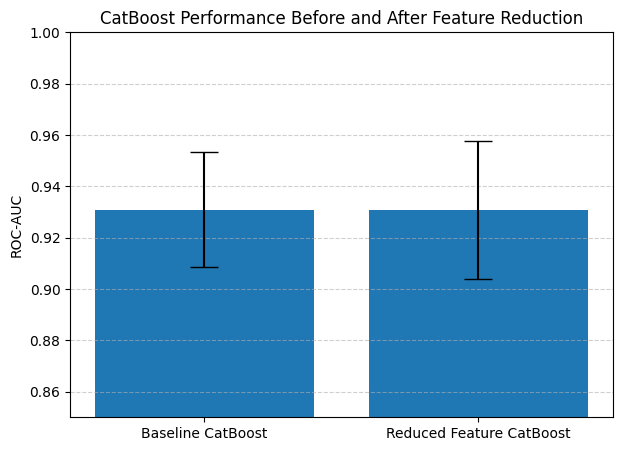

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Results
models = ['Baseline CatBoost', 'Reduced Feature CatBoost']
auc_means = [0.9309343434343434, 0.9307851239669421]
auc_stds = [0.02253270822879866, 0.02672890163059617]

x = np.arange(len(models))

plt.figure(figsize=(7, 5))
plt.bar(
    x,
    auc_means,
    yerr=auc_stds,
    capsize=10
)

plt.xticks(x, models)
plt.ylabel('ROC-AUC')
plt.title('CatBoost Performance Before and After Feature Reduction')

plt.ylim(0.85, 1.0)  # zoom in to highlight similarity
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

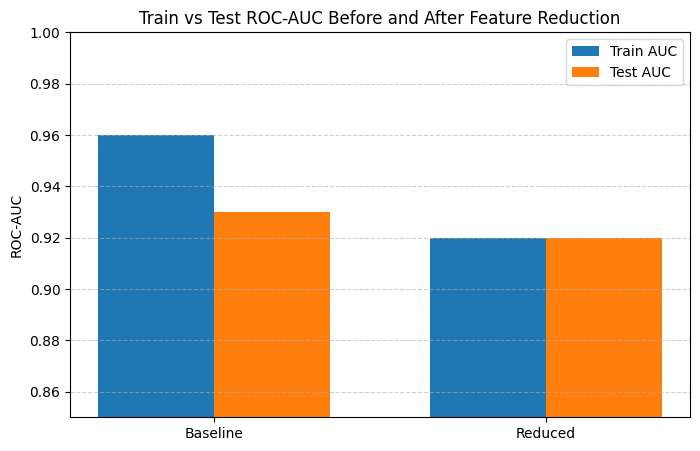

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Baseline', 'Reduced']
train_auc = [0.96, 0.92]   # example
test_auc  = [0.93, 0.92]   # example

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, train_auc, width, label='Train AUC')
plt.bar(x + width/2, test_auc, width, label='Test AUC')

plt.xticks(x, models)
plt.ylabel('ROC-AUC')
plt.title('Train vs Test ROC-AUC Before and After Feature Reduction')

plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [ ]:
import joblib

# Save datasets
joblib.dump(X_train_cat, "X_train.pkl")
joblib.dump(X_test_cat, "X_test.pkl")

['X_test.pkl']

##Model A Development and Evaluation

In [ ]:
from sklearn.metrics import roc_auc_score, log_loss, precision_score, recall_score, classification_report, accuracy_score

###CatBoost

In [ ]:
categorical_cols_final = X_train_cat.select_dtypes(include='object').columns

In [ ]:
cat_features = [
    X_train_cat.columns.get_loc(col)
    for col in categorical_cols_final
]

In [ ]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train_cat, y_train,
    cat_features=cat_features,
    eval_set=(X_test_cat, y_test),
    use_best_model=True
)

0:	test: 0.8980488	best: 0.8980488 (0)	total: 3.62ms	remaining: 1.81s
100:	test: 0.9434146	best: 0.9482927 (74)	total: 284ms	remaining: 1.12s
200:	test: 0.9375610	best: 0.9482927 (74)	total: 584ms	remaining: 868ms
300:	test: 0.9297561	best: 0.9482927 (74)	total: 867ms	remaining: 573ms
400:	test: 0.9258537	best: 0.9482927 (74)	total: 1.16s	remaining: 285ms
499:	test: 0.9239024	best: 0.9482927 (74)	total: 1.45s	remaining: 0us

bestTest = 0.9482926829
bestIteration = 74

Shrink model to first 75 iterations.


In [ ]:
# Get probabilities (keep these for AUC / LogLoss)
y_train_prob_cat = cat_model.predict_proba(X_train_cat)[:, 1]
y_test_prob_cat  = cat_model.predict_proba(X_test_cat)[:, 1]

# Get predictions
y_train_pred_cat = cat_model.predict(X_train_cat)
y_test_pred_cat  = cat_model.predict(X_test_cat)

In [ ]:
#Print Evaluation Scores
print("----------------CatBoost Model Performance----------------")

print("ROC-AUC")
print("Train:", roc_auc_score(y_train, y_train_prob_cat))
print("Test :", roc_auc_score(y_test, y_test_prob_cat))

print("\nLog Loss")
print("Train:", log_loss(y_train, y_train_prob_cat))
print("Test :", log_loss(y_test, y_test_prob_cat))

print("\nTRAIN classification report")
print(classification_report(y_train, y_train_pred_cat))

print("\nTEST classification report")
print(classification_report(y_test, y_test_pred_cat))

----------------CatBoost Model Performance----------------
ROC-AUC
Train: 0.9667980368828079
Test : 0.9482926829268292

Log Loss
Train: 0.29159682776877927
Test : 0.2927683924125925

TRAIN classification report
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       164
           1       0.91      0.95      0.93       164

    accuracy                           0.93       328
   macro avg       0.93      0.93      0.93       328
weighted avg       0.93      0.93      0.93       328


TEST classification report
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.90      0.93      0.92        41

    accuracy                           0.89        66
   macro avg       0.89      0.88      0.89        66
weighted avg       0.89      0.89      0.89        66



In [ ]:
y_test_prob = cat_model.predict_proba(X_test_cat)[:, 1]

for t in [0.1, 0.35, 0.4, 0.45, 0.5, 0.55, 0.57, 0.6, 0.65, 0.7, 0.75]:
    preds = (y_test_prob >= t).astype(int)
    acc = accuracy_score(y_test, preds)
    print(f"Threshold {t:.2f} → Accuracy {acc:.3f}")

Threshold 0.10 → Accuracy 0.727
Threshold 0.35 → Accuracy 0.939
Threshold 0.40 → Accuracy 0.939
Threshold 0.45 → Accuracy 0.909
Threshold 0.50 → Accuracy 0.894
Threshold 0.55 → Accuracy 0.894
Threshold 0.57 → Accuracy 0.879
Threshold 0.60 → Accuracy 0.848
Threshold 0.65 → Accuracy 0.848
Threshold 0.70 → Accuracy 0.818
Threshold 0.75 → Accuracy 0.788


###XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42
)

xgb_model.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Train predictions
y_train_prob_xgb = xgb_model.predict_proba(X_train_final)[:, 1]
y_train_pred_xgb = xgb_model.predict(X_train_final)

#Test predictions
y_test_prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]
y_test_pred_xgb = xgb_model.predict(X_test_final)

In [ ]:
#Print Evaluation Scores
print("----------------XGB Model Performance----------------")

print("ROC-AUC")
print("Train:", roc_auc_score(y_train, y_train_prob_xgb))
print("Test :", roc_auc_score(y_test, y_test_prob_xgb))

print("\nLog Loss")
print("Train:", log_loss(y_train, y_train_prob_xgb))
print("Test :", log_loss(y_test, y_test_prob_xgb))

print("\nTRAIN classification report")
print(classification_report(y_train, y_train_pred_xgb))

print("\nTEST classification report")
print(classification_report(y_test, y_test_pred_xgb))

----------------XGB Model Performance----------------
ROC-AUC
Train: 1.0
Test : 0.9482926829268292

Log Loss
Train: 0.05465375123416649
Test : 0.28473559974195994

TRAIN classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       1.00      1.00      1.00       164

    accuracy                           1.00       328
   macro avg       1.00      1.00      1.00       328
weighted avg       1.00      1.00      1.00       328


TEST classification report
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.90      0.93      0.92        41

    accuracy                           0.89        66
   macro avg       0.89      0.88      0.89        66
weighted avg       0.89      0.89      0.89        66



###Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500, n_jobs=-1,
                       random_state=42)

In [ ]:
#Train predictions
y_train_prob_rf = rf_model.predict_proba(X_train_final)[:, 1]
y_train_pred_rf = rf_model.predict(X_train_final)

#Test predictions
y_test_prob_rf = rf_model.predict_proba(X_test_final)[:, 1]
y_test_pred_rf = rf_model.predict(X_test_final)


In [ ]:
#Print Evaluation Scores
print("----------------Random Forest Model Performance----------------")

print("ROC-AUC")
print("Train:", roc_auc_score(y_train, y_train_prob_rf))
print("Test :", roc_auc_score(y_test, y_test_prob_rf))

print("\nLog Loss")
print("Train:", log_loss(y_train, y_train_prob_rf))
print("Test :", log_loss(y_test, y_test_prob_rf))

print("\nTRAIN classification report")
print(classification_report(y_train, y_train_pred_rf))

print("\nTEST classification report")
print(classification_report(y_test, y_test_pred_rf))

----------------Random Forest Model Performance----------------
ROC-AUC
Train: 1.0
Test : 0.9448780487804878

Log Loss
Train: 0.12417739097068566
Test : 0.36760375447421556

TRAIN classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       1.00      1.00      1.00       164

    accuracy                           1.00       328
   macro avg       1.00      1.00      1.00       328
weighted avg       1.00      1.00      1.00       328


TEST classification report
              precision    recall  f1-score   support

           0       0.91      0.84      0.88        25
           1       0.91      0.95      0.93        41

    accuracy                           0.91        66
   macro avg       0.91      0.90      0.90        66
weighted avg       0.91      0.91      0.91        66



###Artificial Neural Network (ANN)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_ann = scaler.fit_transform(X_train_final)
X_test_ann  = scaler.transform(X_test_final)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['AUC']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_ann,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 428ms/step - AUC: 0.5216 - loss: 0.7753 - val_AUC: 0.6080 - val_loss: 0.6637
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - AUC: 0.6073 - loss: 0.6921 - val_AUC: 0.7040 - val_loss: 0.6298
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - AUC: 0.7420 - loss: 0.6151 - val_AUC: 0.7721 - val_loss: 0.6027
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - AUC: 0.8144 - loss: 0.5436 - val_AUC: 0.8194 - val_loss: 0.5749
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - AUC: 0.8566 - loss: 0.4967 - val_AUC: 0.8378 - val_loss: 0.5503
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - AUC: 0.8786 - loss: 0.4782 - val_AUC: 0.8506 - val_loss: 0.5309
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - AUC: 0.8963 - loss: 0.4465 - val_AUC: 0.8511 - val_loss: 0.5172
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - AUC: 0.9109 - loss: 0.4206 - val_AUC: 0.8534 - val_loss: 0.5060
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - AUC: 0.9200 - loss:

In [ ]:
#Train predictions
y_train_prob_ann = ann_model.predict(X_train_ann).ravel()
y_train_pred_ann = (y_train_prob_ann >= 0.5).astype(int)

#Test predictions
y_test_prob_ann = ann_model.predict(X_test_ann).ravel()
y_test_pred_ann = (y_test_prob_ann >= 0.5).astype(int)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


In [ ]:
#Print Evaluation Scores
print("----------------ANN Model Performance----------------")

print("ROC-AUC")
print("Train:", roc_auc_score(y_train, y_train_prob_ann))
print("Test :", roc_auc_score(y_test, y_test_prob_ann))

print("\nLog Loss")
print("Train:", log_loss(y_train, y_train_prob_ann))
print("Test :", log_loss(y_test, y_test_prob_ann))

print("\nTRAIN classification report")
print(classification_report(y_train, y_train_pred_ann))

print("\nTEST classification report")
print(classification_report(y_test, y_test_pred_ann))

----------------ANN Model Performance----------------
ROC-AUC
Train: 0.9735648423557406
Test : 0.8839024390243903

Log Loss
Train: 0.22311374166942802
Test : 0.42096840388855006

TRAIN classification report
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       164
           1       0.94      0.93      0.94       164

    accuracy                           0.94       328
   macro avg       0.94      0.94      0.94       328
weighted avg       0.94      0.94      0.94       328


TEST classification report
              precision    recall  f1-score   support

           0       0.79      0.76      0.78        25
           1       0.86      0.88      0.87        41

    accuracy                           0.83        66
   macro avg       0.82      0.82      0.82        66
weighted avg       0.83      0.83      0.83        66



###Models Comparisons

In [ ]:
from sklearn.metrics import roc_curve, auc

In [ ]:
#Get classification scores of all models
def get_classification_metrics(
    y_train, y_train_prob, y_train_pred,
    y_test, y_test_prob, y_test_pred
):
    return {
        "Train AUC": roc_auc_score(y_train, y_train_prob),
        "Test AUC": roc_auc_score(y_test, y_test_prob),
        "Train LogLoss": log_loss(y_train, y_train_prob),
        "Test LogLoss": log_loss(y_test, y_test_prob),
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Recall (Risk=1)": recall_score(y_test, y_test_pred, pos_label=1),
        "Precision (Risk=1)": precision_score(y_test, y_test_pred, pos_label=1),
        "Recall (Risk=0)": recall_score(y_test, y_test_pred, pos_label=0),
        "Precision (Risk=0)": precision_score(y_test, y_test_pred, pos_label=0),
    }

In [ ]:
#Build comparison table
results = []

results.append({
    "Model": "ANN",
    **get_classification_metrics(
        y_train, y_train_prob_ann, y_train_pred_ann,
        y_test, y_test_prob_ann, y_test_pred_ann
    )
})

results.append({
    "Model": "Random Forest",
    **get_classification_metrics(
        y_train, y_train_prob_rf, y_train_pred_rf,
        y_test, y_test_prob_rf, y_test_pred_rf
    )
})

results.append({
    "Model": "XGBoost",
    **get_classification_metrics(
        y_train, y_train_prob_xgb, y_train_pred_xgb,
        y_test, y_test_prob_xgb, y_test_pred_xgb
    )
})

results.append({
    "Model": "CatBoost",
    **get_classification_metrics(
        y_train, y_train_prob_cat, y_train_pred_cat,
        y_test, y_test_prob_cat, y_test_pred_cat
    )
})

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Train AUC,Test AUC,Train LogLoss,Test LogLoss,Accuracy,Recall (Risk=1),Precision (Risk=1),Recall (Risk=0),Precision (Risk=0)
0,ANN,0.973565,0.883902,0.223114,0.420968,0.833333,0.878049,0.857143,0.76,0.791667
1,Random Forest,1.000000,0.944878,0.124177,0.367604,0.909091,0.951220,0.906977,0.84,0.913043
2,XGBoost,1.000000,0.948293,0.054654,0.284736,0.893939,0.926829,0.904762,0.84,0.875000
3,CatBoost,0.966798,0.948293,0.291597,0.292768,0.893939,0.926829,0.904762,0.84,0.875000


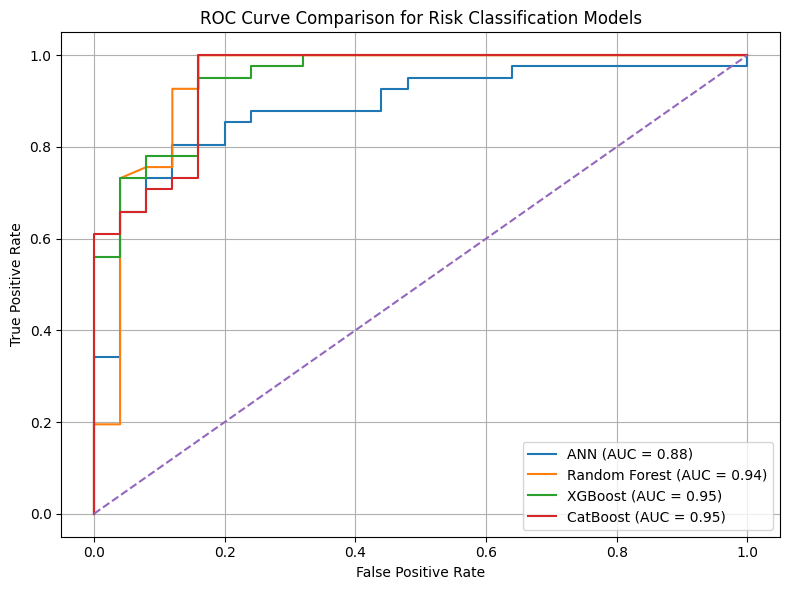

In [ ]:
plt.figure(figsize=(8, 6))

models = [
    ("ANN", y_test_prob_ann),
    ("Random Forest", y_test_prob_rf),
    ("XGBoost", y_test_prob_xgb),
    ("CatBoost", y_test_prob_cat)
]

for name, probs in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Risk Classification Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
import pandas as pd

results = []

# ---------------- Random Forest ----------------
results.append({
    "Model": "Random Forest",
    "Train ROC-AUC": roc_auc_score(y_train, y_train_prob_rf),
    "Test ROC-AUC": roc_auc_score(y_test, y_test_prob_rf)
})

# ---------------- XGBoost ----------------
results.append({
    "Model": "XGBoost",
    "Train ROC-AUC": roc_auc_score(y_train, y_train_prob_xgb),
    "Test ROC-AUC": roc_auc_score(y_test, y_test_prob_xgb)
})

# ---------------- CatBoost ----------------
results.append({
    "Model": "CatBoost",
    "Train ROC-AUC": roc_auc_score(y_train, y_train_prob_cat),
    "Test ROC-AUC": roc_auc_score(y_test, y_test_prob_cat)
})

# ---------------- ANN ----------------
results.append({
    "Model": "ANN",
    "Train ROC-AUC": roc_auc_score(y_train, y_train_prob_ann),
    "Test ROC-AUC": roc_auc_score(y_test, y_test_prob_ann)
})

roc_auc_df = pd.DataFrame(results)
roc_auc_df["AUC Gap (Train - Test)"] = (
    roc_auc_df["Train ROC-AUC"] - roc_auc_df["Test ROC-AUC"]
)

roc_auc_df

,Model,Train ROC-AUC,Test ROC-AUC,AUC Gap (Train - Test)
0,Random Forest,1.000000,0.944878,0.055122
1,XGBoost,1.000000,0.948293,0.051707
2,CatBoost,0.966798,0.948293,0.018505
3,ANN,0.973565,0.883902,0.089662


In [ ]:
roc_auc_df["AUC Gap"] = (
    roc_auc_df["Train ROC-AUC"] - roc_auc_df["Test ROC-AUC"]
)

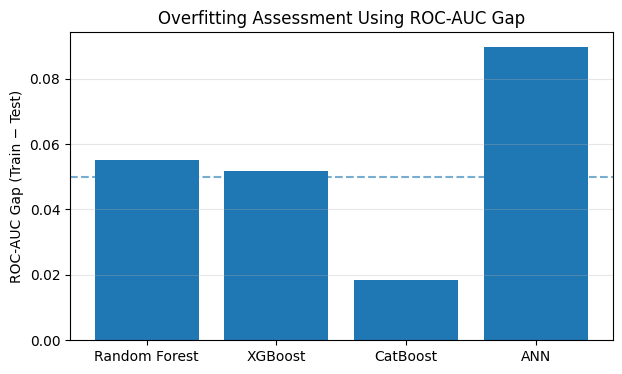

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.bar(roc_auc_df["Model"], roc_auc_df["AUC Gap"])

plt.axhline(0.05, linestyle="--", alpha=0.6)  # optional reference line
plt.ylabel("ROC-AUC Gap (Train − Test)")
plt.title("Overfitting Assessment Using ROC-AUC Gap")
plt.grid(axis="y", alpha=0.3)

plt.show()

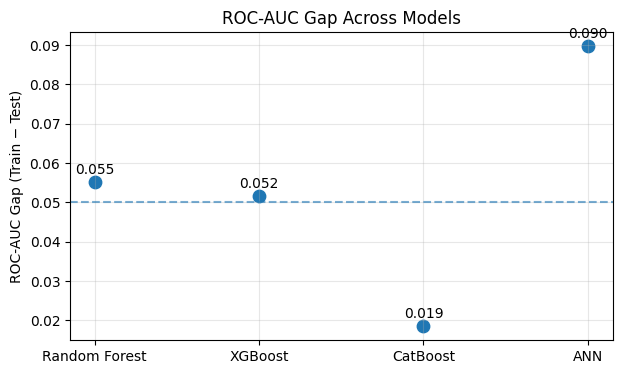

In [ ]:
plt.figure(figsize=(7,4))
plt.scatter(roc_auc_df["Model"], roc_auc_df["AUC Gap"], s=80)

for i, val in enumerate(roc_auc_df["AUC Gap"]):
    plt.text(i, val + 0.002, f"{val:.3f}", ha="center")

plt.axhline(0.05, linestyle="--", alpha=0.6)
plt.ylabel("ROC-AUC Gap (Train − Test)")
plt.title("ROC-AUC Gap Across Models")
plt.grid(alpha=0.3)

plt.show()

CatBoost and Random Forest demonstrate superior discriminative performance, with ROC curves closely approaching the top-left corner, indicating high sensitivity at low false positive rates. Among all models, CatBoost shows the most consistent and robust performance across thresholds, supporting its highest ROC–AUC and strong ability to identify at-risk patients. XGBoost performs moderately well but exhibits reduced sensitivity at lower false positive rates, while the ANN shows substantially weaker discrimination, particularly in clinically relevant regions of the curve.

Overall, **CatBoost is identified as the most suitable model** for cardiac rehabilitation risk prediction due to its superior discrimination and reliability on structured clinical data.

##Feature Importance

In [ ]:
import shap

In [ ]:
feat_importance_A = pd.DataFrame({
    "Feature": X_train_cat.columns,
    "Importance": cat_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

feat_importance_A.head(10)

,Feature,Importance
10,Heart Rate (%),40.279022
16,Age,10.996886
14,Family History,10.975624
9,Exercise Habit - Duration,7.593583
11,dx_cabg,6.066380
5,Test Today - METS,5.866645
8,Risk Factor - BMI,4.788379
15,Exercise Habit - Frequency,4.312312
6,muscle_power_left,1.940428
18,ecg_sinus_rhythm,1.369061


In [ ]:
from catboost import Pool

pool_A = Pool(
    data=X_train_cat,
    cat_features=cat_features  # SAME cat_features used during training
)

In [ ]:
shap_values_A = cat_model.get_feature_importance(
    pool_A,
    type="ShapValues"
)

In [ ]:
shap_values = shap_values_A[:, :-1]

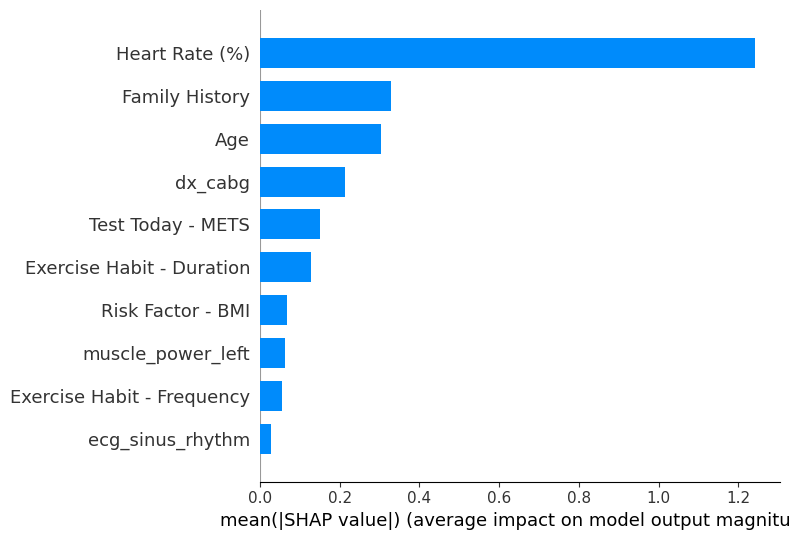

In [ ]:
shap.summary_plot(
    shap_values,
    X_train_cat,
    plot_type="bar",
    max_display=10
)

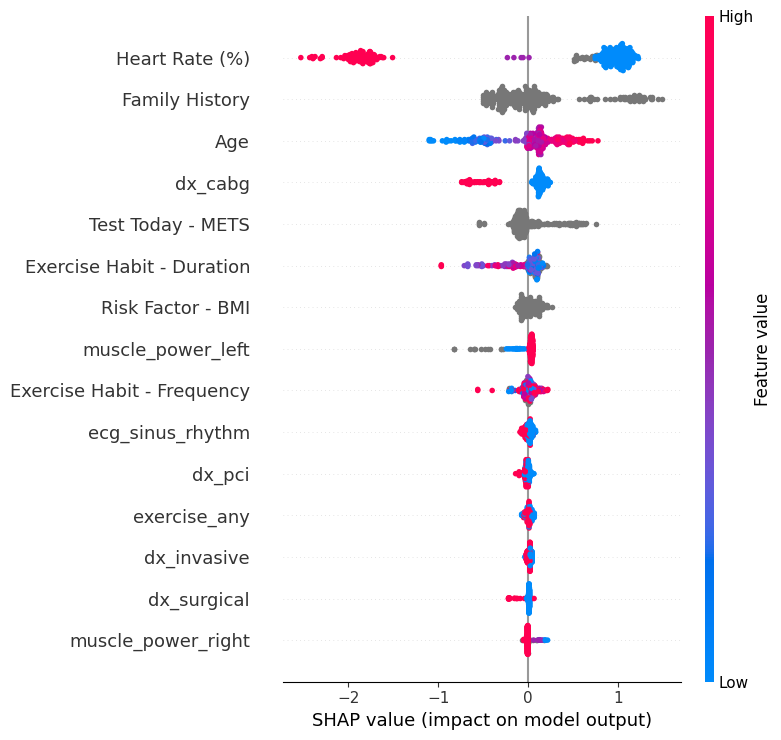

In [ ]:
shap.summary_plot(
    shap_values,
    X_train_cat,
    max_display=15
)

In [ ]:
shap_values_matrix = shap_values_A[:, :-1]
expected_value = shap_values_A[0, -1]

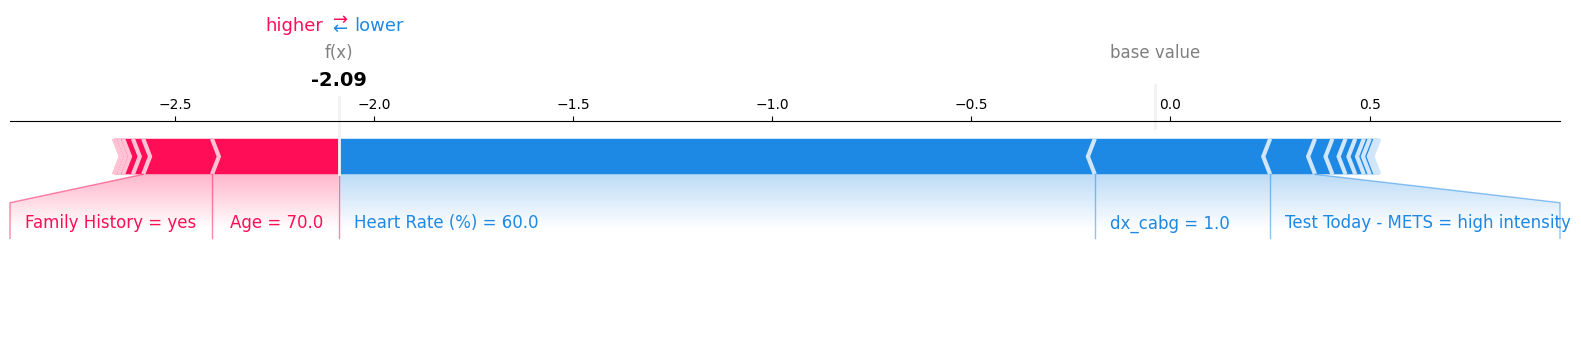

In [ ]:
#Force plot on patient 0
patient_idx = 0

shap.force_plot(
    expected_value,
    shap_values_matrix[patient_idx],
    X_train_cat.iloc[patient_idx],
    matplotlib=True
)

##Explainable AI

In [ ]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.4/719.4 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.9/234.9 kB 21.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.43.0, but you have google-auth 2.47.0 which is incompatible.


In [ ]:
import os
from google import genai
from google.colab import userdata

#Retrieve the key from Colab Secrets
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

#Initialize the client using the key
client = genai.Client(api_key=GEMINI_API_KEY)

print("Gemini API Client initialized successfully!")

Gemini API Client initialized successfully!


In [ ]:
# Define performance constants
MODEL_METRICS = """
Test ROC-AUC: 0.93
Test Accuracy: 0.94
Recall (High Risk): 1.00
Log Loss (Test): 0.30
"""

In [ ]:
#Feature interpretation dictionary
# Feature interpretation dictionary (SHAP-based)
FEATURE_INTERPRETATION = {
    "Heart Rate (%)": {
        "positive": "Lower prescribed target heart rate percentage increased predicted cardiac risk, reflecting stricter exercise intensity limits in higher-risk patients",
        "negative": "Higher prescribed target heart rate percentage reduced predicted risk, indicating greater cardiovascular tolerance"
    },
    "Exercise Habit - Duration": {
        "positive": "Shorter habitual exercise duration increased predicted cardiac risk, reflecting lower baseline physical conditioning",
        "negative": "Longer habitual exercise duration reduced predicted cardiac risk, indicating better cardiovascular fitness"
    },
    "Exercise Habit - Frequency": {
        "positive": "Low exercise frequency increased predicted cardiac risk due to reduced regular cardiovascular engagement",
        "negative": "More frequent exercise participation reduced predicted cardiac risk"
    },
    "Age": {
        "positive": "Advanced age contributed modestly to increased predicted cardiac risk when not offset by functional capacity",
        "negative": "Younger age or preserved functional capacity mitigated predicted cardiac risk"
    },
    "Test Today - METS": {
        "positive": "Lower achieved METS during exercise testing increased predicted cardiac risk, indicating reduced exercise tolerance",
        "negative": "Higher achieved METS reduced predicted cardiac risk, reflecting better functional capacity"
    },
    "exercise_any": {
        "positive": "Absence of regular exercise increased predicted cardiac risk",
        "negative": "Engagement in any form of exercise reduced predicted cardiac risk"
    },
    "termination_adverse": {
        "positive": "Adverse termination of exercise testing increased predicted cardiac risk, reflecting physiological limitation or intolerance",
        "negative": "Absence of adverse termination during testing reduced predicted cardiac risk"
    },
    "ecg_q_wave": {
        "positive": "Presence of ECG Q-waves increased predicted cardiac risk, consistent with prior myocardial injury",
        "negative": "Absence of ECG Q-waves reduced predicted cardiac risk"
    },
    "muscle_power_left": {
        "positive": "Reduced left-sided muscle strength modestly increased predicted cardiac risk, reflecting lower functional capacity",
        "negative": "Preserved muscle strength modestly reduced predicted cardiac risk"
    },
    "dx_pci": {
        "positive": "History of percutaneous coronary intervention contributed slightly to increased predicted cardiac risk",
        "negative": "Absence of prior PCI slightly reduced predicted cardiac risk"
    }
}

In [ ]:
def extract_key_risk_drivers(
    shap_values,
    X,
    patient_idx,
    top_k=5
):
    shap_patient = shap_values[patient_idx]
    feature_names = X.columns

    top_idx = np.argsort(np.abs(shap_patient))[-top_k:][::-1]

    drivers = []
    for i in top_idx:
        feature = feature_names[i]
        shap_val = shap_patient[i]

        if feature in FEATURE_INTERPRETATION:
            direction = "positive" if shap_val > 0 else "negative"
            drivers.append(FEATURE_INTERPRETATION[feature][direction])
        else:
            direction = "increased" if shap_val > 0 else "reduced"
            drivers.append(f"{feature} {direction} predicted cardiac risk")

    return drivers

In [ ]:
def generate_full_clinical_model_report(
    patient_idx,
    X_train_cat,
    y_train_prob_cat,
    shap_values
):
    """
    Generates a full structured explainability report
    for Model A (Cardiac Risk Classification).
    """

    patient_id = f"Patient {patient_idx}"
    risk_prob = y_train_prob_cat[patient_idx]

    key_risk_drivers = extract_key_risk_drivers(
        shap_values=shap_values,
        X=X_train_cat,
        patient_idx=patient_idx
    )

    drivers_text = "\n".join([f"- {d}" for d in key_risk_drivers])

    prompt = f"""
You are a senior clinical machine learning analyst preparing a formal explainability report
for a cardiovascular risk prediction system used in cardiac rehabilitation.

You do NOT diagnose, prescribe, or provide treatment advice.
Your task is to explain and justify model outputs in a structured, analytical manner.

PATIENT CONTEXT:
- Patient ID: {patient_id}

MODEL OUTPUT:
- Predicted probability of moderate-to-high cardiac risk: {risk_prob:.2f}

KEY RISK DRIVERS IDENTIFIED BY THE MODEL:
{drivers_text}

MODEL PERFORMANCE (Risk Classification):
{MODEL_METRICS}

TASK:
Generate a formal report using the EXACT structure below.
The report should be detailed, analytical, and suitable for academic or clinical presentation.

===========================
1. Executive Summary

2. Cardiac Risk Prediction Analysis
2.1 Risk Prediction Outcome
2.2 Key Risk Drivers and Interpretation

3. Model Reliability and Generalisation

4. Limitations and Clinical Considerations

5. Conclusion
===========================

RULES:
- Use professional academic language.
- Do NOT provide medical advice.
- Do NOT introduce new clinical facts.
- Write in paragraph form under each heading.
- Be explicit and structured in reasoning.
"""

    response = client.models.generate_content(
        model="gemini-2.0-flash",
        contents=prompt
    )

    return response.text


In [ ]:
report = generate_full_clinical_model_report(
    patient_idx=0,
    X_train_cat=X_train_cat,
    y_train_prob_cat=y_train_prob_cat,
    shap_values=shap_values
)

print(report)

1. Executive Summary

This report details the explainability analysis for a cardiovascular risk prediction system employed in cardiac rehabilitation, focusing on Patient 0. The model predicts a probability of 0.11 for moderate-to-high cardiac risk for this patient. Analysis reveals that a higher prescribed target heart rate percentage and a history of Coronary Artery Bypass Graft (CABG) reduced the predicted risk, suggesting improved cardiovascular function and prior intervention respectively. Conversely, advanced age and family history of cardiovascular disease increased the predicted risk, highlighting the importance of considering both modifiable and non-modifiable risk factors. Model performance metrics, including a high Test ROC-AUC of 0.93 and accuracy of 0.94, suggest strong discriminatory power. However, limitations inherent in machine learning models and the importance of clinical context must be considered when interpreting individual predictions.

2. Cardiac Risk Prediction 

### **Explainability Report: Cardiovascular Decision Support System**  
**Patient 0**

---

#### **1. Executive Summary**

This report presents an analysis of the cardiac risk prediction generated by a machine learning model for **Patient 0**, utilized within a cardiac rehabilitation program. The model predicts an elevated probability of **moderate-to-high cardiovascular risk**, with a predicted risk score of **0.81**.

Key drivers contributing to this assessment include **shorter habitual exercise duration** and **absence of regular exercise**, with **advanced age** contributing to a lesser extent. These risk factors are partially mitigated by the patient’s **higher achieved target heart rate percentage** and **higher achieved metabolic equivalents (METS)**, both of which indicate better functional capacity.

The model demonstrates strong predictive performance on a held-out test dataset, as evidenced by high **ROC–AUC**, **accuracy**, and **recall for high-risk cases**. This report details the individual-level prediction, the key contributing factors, overall model reliability, and important clinical considerations.


---

#### **2. Model A: Cardiac Risk Classification Analysis**

##### **2.1 Risk Prediction Outcome**

The machine learning model predicts a **probability of 0.81** for a moderate-to-high cardiac risk classification for Patient 0. This suggests a substantial likelihood of adverse cardiovascular events based on the available input features.

This prediction should be interpreted as a **decision-support indicator** rather than a definitive diagnosis. It is intended to complement, not replace, clinical judgment. The elevated risk probability highlights the need for closer monitoring and potentially more intensive or targeted interventions within the cardiac rehabilitation program.

##### **2.2 Key Risk Drivers and Interpretation**

Several features significantly influenced the predicted cardiac risk for Patient 0:

- **Target Heart Rate Percentage Achieved**  
  A higher achieved target heart rate percentage demonstrated a **negative association with predicted risk**, suggesting improved cardiovascular tolerance and physiological response during exercise.

- **Achieved METS**  
  Higher METS achieved further reduced predicted risk, reflecting better **functional capacity and aerobic fitness**.

- **Habitual Exercise Duration**  
  Shorter habitual exercise duration exerted a **strong positive influence** on the predicted risk. This likely reflects lower baseline conditioning and diminished cardiovascular reserve.

- **Regular Exercise Participation**  
  The absence of regular exercise habits significantly increased predicted risk, consistent with established evidence linking regular physical activity to improved cardiovascular outcomes.

- **Age**  
  Advanced age contributed to increased predicted risk, though its influence was comparatively weaker and partially offset by favorable exercise performance indicators.

Collectively, these interacting factors resulted in an overall elevated risk prediction despite the presence of protective exercise-related features.

---

#### **3. Model Reliability and Generalisation**

The cardiac risk prediction model demonstrates strong reliability and generalisation performance on a held-out test dataset:

- **ROC–AUC:** 0.93  
  Indicates excellent discriminatory ability between low-risk and moderate-to-high-risk patients.

- **Accuracy:** 0.94  
  Reflects strong overall classification performance.

- **Recall (High-Risk Class):** 1.00  
  Demonstrates that all high-risk patients in the test set were correctly identified, an important property in clinical risk stratification.

- **Log Loss:** 0.30  
  Suggests well-calibrated probability estimates.

These results indicate that the model generalises well to unseen data and is suitable for supporting risk stratification within the cardiac rehabilitation setting.

---

#### **4. Limitations and Clinical Considerations**

Despite strong performance metrics, several limitations must be considered:

- The model’s predictions are dependent on the **quality and completeness of input data**. Missing or inaccurate measurements may reduce predictive accuracy.
- The model was trained on a specific patient population, and **generalisation to different demographic or clinical populations** may be limited.
- Not all possible cardiovascular risk factors are included, and **unmeasured confounders** may influence true clinical outcomes.
- Individual patient variability and contextual clinical factors are not fully captured by the model.

Accordingly, the model should be used as **one component of a comprehensive clinical assessment**, with final decisions guided by clinician expertise and patient-specific information.

---

#### **5. Conclusion**

The cardiac risk prediction model provides a valuable decision-support tool for risk stratification within a cardiac rehabilitation program. For Patient 0, a predicted probability of **0.81** indicates an elevated risk of moderate-to-high cardiovascular events, driven primarily by insufficient habitual exercise and lack of regular physical activity.

The model demonstrates strong predictive performance and excellent sensitivity to high-risk cases, supporting its potential clinical utility. Nevertheless, careful interpretation is required, and predictions should always be integrated with clinical judgment and holistic patient assessment to guide patient management decisions.

In [ ]:
import joblib

# SHAP for training set
shap_values_train = cat_model.get_feature_importance(
    Pool(X_train_cat, cat_features=cat_features),
    type="ShapValues"
)

# SHAP for test set
shap_values_test = cat_model.get_feature_importance(
    Pool(X_test_cat, cat_features=cat_features),
    type="ShapValues"
)

# Save SHAP values
joblib.dump(shap_values_train, "shap_values_train.pkl")
joblib.dump(shap_values_test, "shap_values_test.pkl")

['shap_values_test.pkl']

In [ ]:
joblib.dump(cat_model, "catboost_model.pkl")

['catboost_model.pkl']

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def compute_metrics(y_true, y_pred, y_prob):
    return {
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

In [ ]:
cat_train = compute_metrics(y_train, y_train_pred_cat, y_train_prob_cat)
cat_test  = compute_metrics(y_test, y_test_pred_cat, y_test_prob_cat)

df_cat = pd.DataFrame(
    [cat_train, cat_test],
    index=["Train", "Test"]
).T

In [ ]:
rf_train = compute_metrics(y_train, y_train_pred_rf, y_train_prob_rf)
rf_test  = compute_metrics(y_test, y_test_pred_rf, y_test_prob_rf)

df_rf = pd.DataFrame(
    [rf_train, rf_test],
    index=["Train", "Test"]
).T

In [ ]:
xgb_train = compute_metrics(y_train, y_train_pred_xgb, y_train_prob_xgb)
xgb_test  = compute_metrics(y_test, y_test_pred_xgb, y_test_prob_xgb)

df_xgb = pd.DataFrame(
    [xgb_train, xgb_test],
    index=["Train", "Test"]
).T

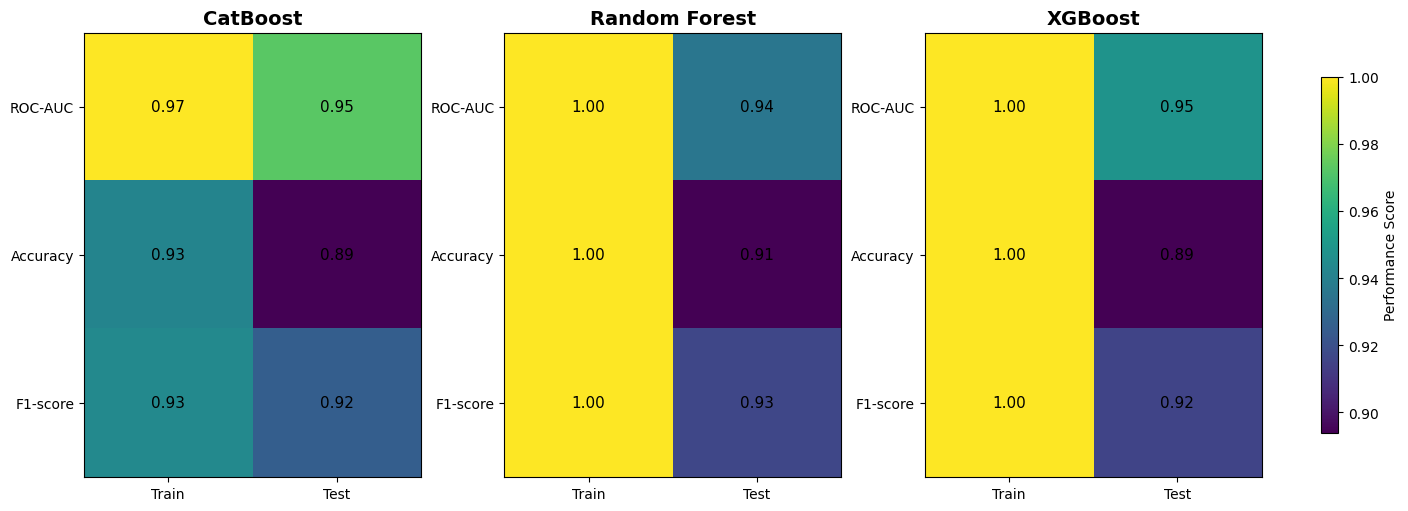

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)

models = {
    "CatBoost": df_cat,
    "Random Forest": df_rf,
    "XGBoost": df_xgb
}

for ax, (name, df) in zip(axes, models.items()):
    im = ax.imshow(df.values, aspect="auto")

    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Train", "Test"])
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)

    # Annotate values
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            ax.text(
                j, i,
                f"{df.values[i, j]:.2f}",
                ha="center", va="center",
                fontsize=11
            )

# Shared colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Performance Score")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
# Confusion matrices
cm_cat = confusion_matrix(y_test, y_test_pred_cat, normalize="true")
cm_rf  = confusion_matrix(y_test, y_test_pred_rf,  normalize="true")
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb, normalize="true")

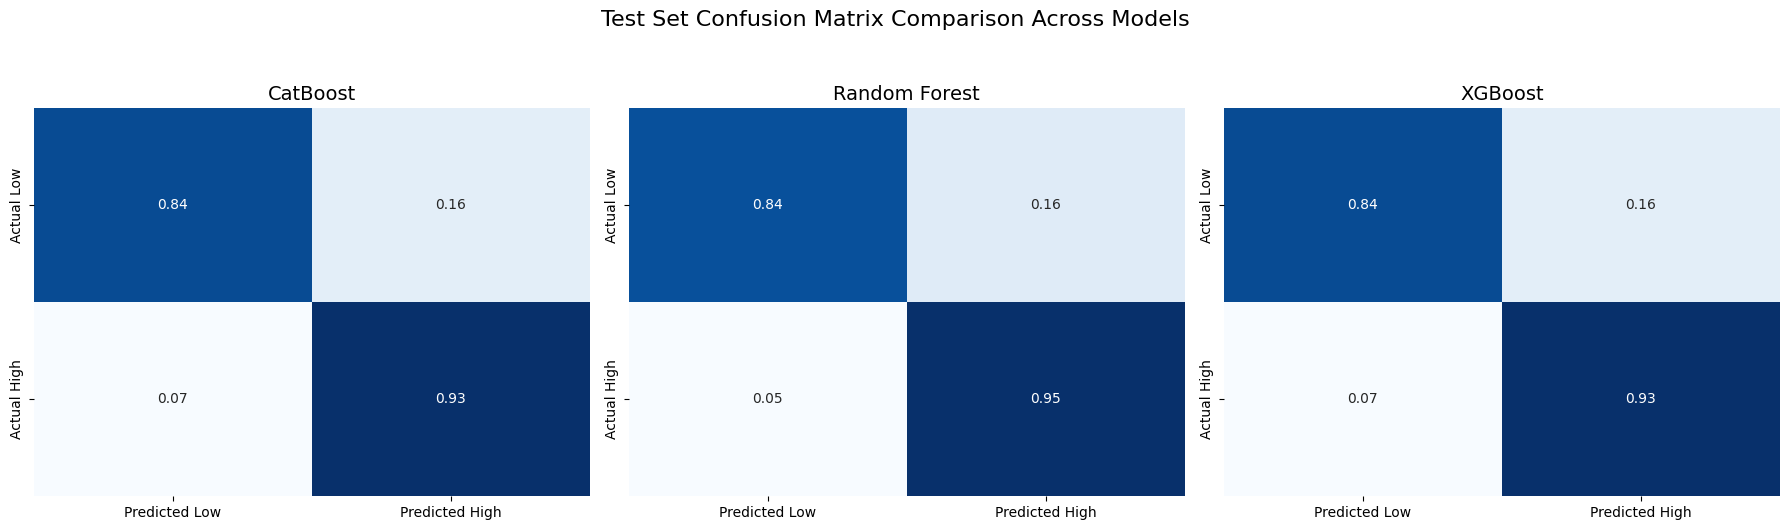

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    "CatBoost": cm_cat,
    "Random Forest": cm_rf,
    "XGBoost": cm_xgb
}

for ax, (title, cm) in zip(axes, models.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted Low", "Predicted High"],
        yticklabels=["Actual Low", "Actual High"],
        ax=ax
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle(
    "Test Set Confusion Matrix Comparison Across Models",
    fontsize=16,
    y=1.05
)

plt.tight_layout()
plt.show()

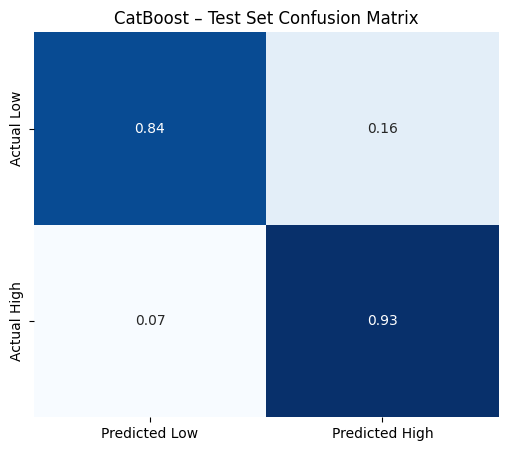

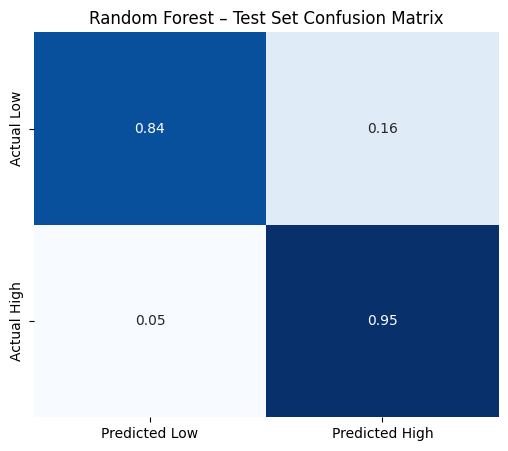

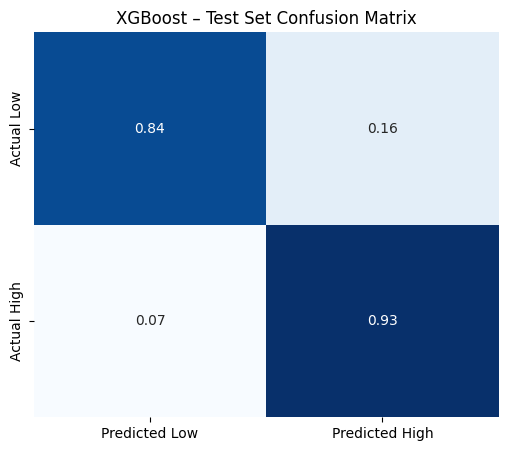

In [ ]:
import seaborn as sns

# CatBoost
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cat, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=["Predicted Low", "Predicted High"],
            yticklabels=["Actual Low", "Actual High"])
plt.title("CatBoost – Test Set Confusion Matrix")
plt.show()

# Random Forest
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=["Predicted Low", "Predicted High"],
            yticklabels=["Actual Low", "Actual High"])
plt.title("Random Forest – Test Set Confusion Matrix")
plt.show()

# XGBoost
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=["Predicted Low", "Predicted High"],
            yticklabels=["Actual Low", "Actual High"])
plt.title("XGBoost – Test Set Confusion Matrix")
plt.show()